# Three Steps MultiFidelity Neural Network

In [1]:

#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.callbacks import ModelCheckpoint
# import warnings
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from keras.models import save_model
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf



In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [3]:
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [4]:
#file_path_LF = "../DATA/reaction_diffusion_LF_28_d1.mat"
#(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

In [5]:
########################     NORMALIZATION  #########################
# Input
reaction_HF_test=normalization(reaction_HF_test)

In [6]:
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoLin =1500
NepoHF = 3000  # number of epochs for second NN: NN_HF 
Nlf=30
n_HF = 15


In [7]:


reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

U_HF_test = U_HF_test[ :,-1, 44,44]
U_HF_test = normalization(U_HF_test)
permutation = np.random.permutation(len(reaction_HF_test))


In [8]:
U_LF_list = []
U_Lin_list = []
U_HF_list = []


r2_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])


## Neural Network
Cycle on the Discretization and the value of the diffusion

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************


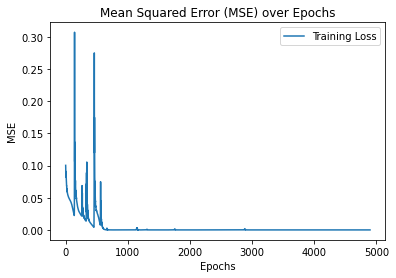

2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.11892544874697966
R^2: 0.045405584853972836
1/1 [==============================] - 0s 21ms/step


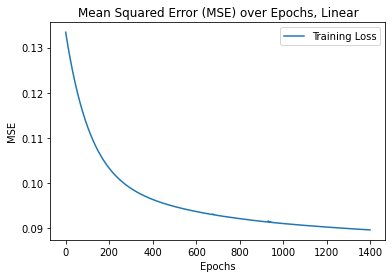

2/2 [==============================] - 0s 0s/step


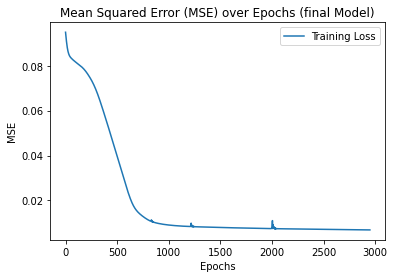

2/2 [==============================] - 0s 0s/step
Elapsed time:  25.51352829998359
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.23209197878214527
R^2: -1.0503044683001677

HF Model:
Test MSE: 0.7351535901039299
R^2: -5.494359256128468
2/2 [==============================] - 0s 0s/step


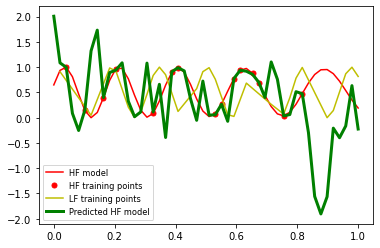

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************


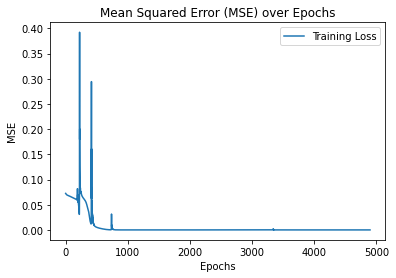

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0939716662690532
R^2: 0.17395986132684482
1/1 [==============================] - 0s 29ms/step


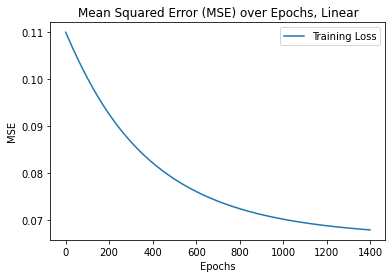

2/2 [==============================] - 0s 0s/step


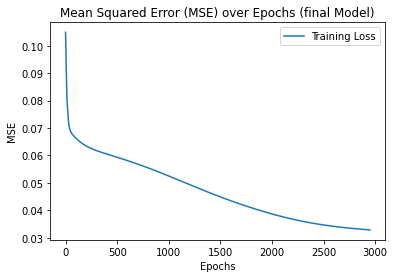

2/2 [==============================] - 0s 10ms/step
Elapsed time:  24.206864800071344
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.08295618908048662
R^2: 0.26716362177890207

HF Model:
Test MSE: 0.17744771879880036
R^2: -0.5675761508516237
2/2 [==============================] - 0s 4ms/step


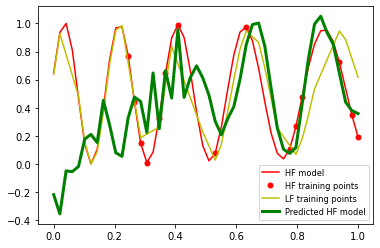

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************


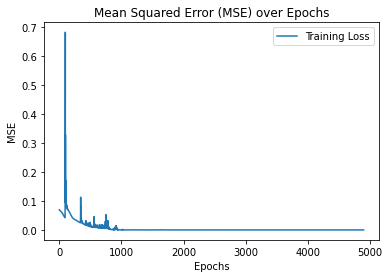

2/2 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.1525656637102674
R^2: -0.2952542070571713
1/1 [==============================] - 0s 24ms/step


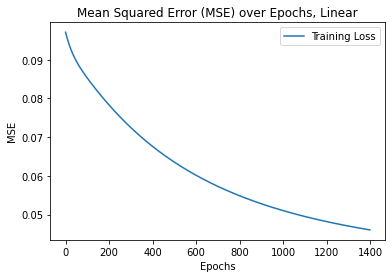

2/2 [==============================] - 0s 0s/step


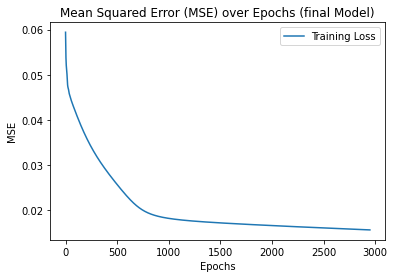

2/2 [==============================] - 0s 0s/step
Elapsed time:  23.830551399849355
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.09745876444004976
R^2: 0.13904762562255535

HF Model:
Test MSE: 0.10618885299754156
R^2: 0.06192587556464857
2/2 [==============================] - 0s 12ms/step


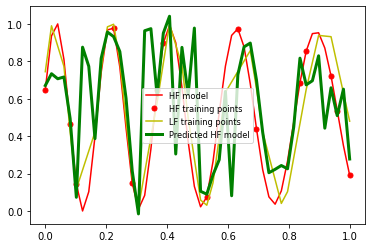

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************


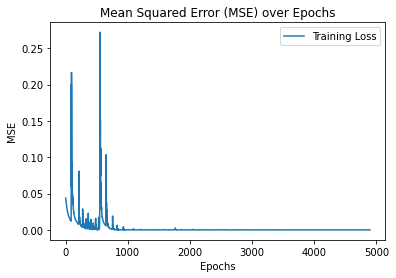

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.18279734861082989
R^2: -0.5791752994750974
1/1 [==============================] - 0s 16ms/step


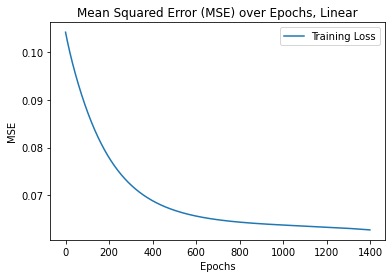

2/2 [==============================] - 0s 3ms/step


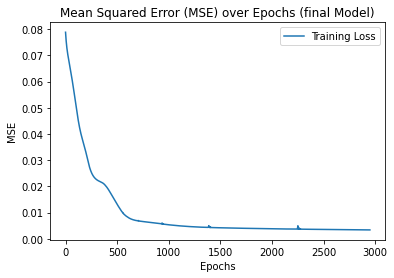

2/2 [==============================] - 0s 0s/step
Elapsed time:  24.09751099999994
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.12313117116954646
R^2: -0.0877428498850612

HF Model:
Test MSE: 0.21907714629378255
R^2: -0.9353312178453737
2/2 [==============================] - 0s 16ms/step


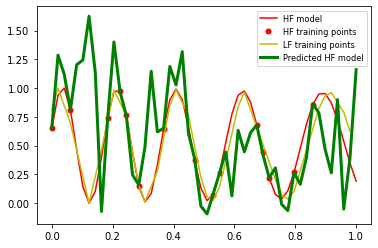

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************


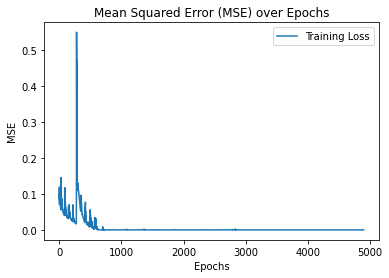

2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.10055234353815518
R^2: 0.19319586037695136
1/1 [==============================] - 0s 23ms/step


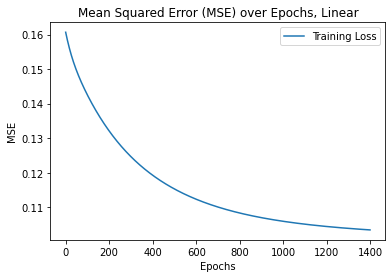

2/2 [==============================] - 0s 5ms/step


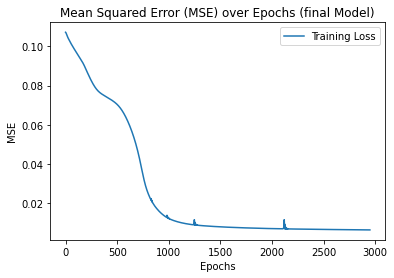

2/2 [==============================] - 0s 5ms/step
Elapsed time:  24.950974700041115
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.1176049956388721
R^2: -0.038924521726516836

HF Model:
Test MSE: 2.0345042650678313
R^2: -16.972845107929352
2/2 [==============================] - 0s 3ms/step


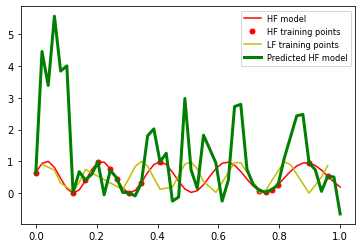

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************


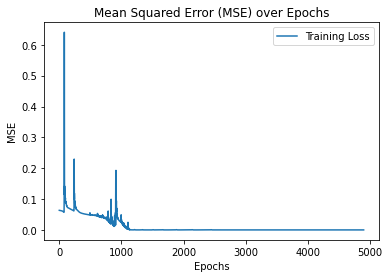

2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.052411102852598764
R^2: 0.537239306845902
1/1 [==============================] - 0s 27ms/step


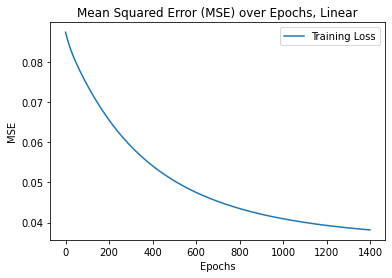

2/2 [==============================] - 0s 3ms/step


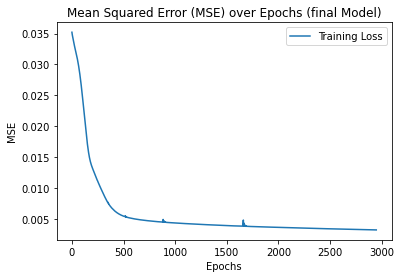

2/2 [==============================] - 0s 4ms/step
Elapsed time:  27.173163700150326
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.05373615931716609
R^2: 0.525293859204448

HF Model:
Test MSE: 0.11883489321040928
R^2: -0.04978945768727727
2/2 [==============================] - 0s 0s/step


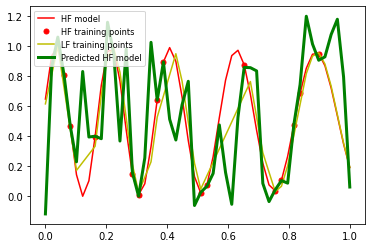

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************


KeyboardInterrupt: 

In [9]:
#checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)
test_mse_HF_list = []
test_mse_LF_list = []
test_mse_Lin_list = []

r2_HF_list = []
r2_LF_list = []
r2_Lin_list = []
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_HF = reaction_HF_test[permutation,:][0:n_HF,:]
        U_HF = U_HF_test[permutation][0:n_HF]
        
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        
        reaction_LF_test=normalization(reaction_LF_test)
        U_LF_test=normalization(U_LF_test)
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_train_LF = U_LF_test[permutation][0:Nlf]

        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
        reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
 

       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        
        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        #reaction_test_in = np.vstack(
        #    (reaction_HF_test[:, 0], reaction_test_help)
        #).transpose()  # <- TEST INPUT for the second NN: NN_Lin
        reaction_test_in=np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )
        
        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        # reaction_lin = np.vstack(
        #     (reaction_HF[:, 0], reaction_train_help)
        # ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin
        reaction_lin=np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )
        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )
        plt.plot(modelLin.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs, Linear')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        ULin = modelLin.predict(
            np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1), reaction_help1.reshape(-1,1)),axis=1
        )

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1), reaction_test_help1.reshape(-1,1)),axis=1
        )

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best parameters obtained by HPO:
        
        best_params={'kernel_init': 'glorot_uniform', 'l2weight': 0.0001933368067753076, 'lr': 0.004404993622688278, 'nodes': 10.0, 'opt': 'Adam'}
        #0.0001933368067753076
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
        )

        plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
#
        # ULin = modelLin.predict(
        #     np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        # )
        ULin=modelLin.predict(np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        ))
        
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "ro",
        markersize=5,
        label="HF training points",
        )
        order=np.argsort(reaction_LF[:,0])
        plt.plot(
        reaction_LF[order,0],
        U_train_LF[order],
        "y-",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g-",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
    
        
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        # r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        # r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}
        # r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        # mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        # mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_Lin_list[-1]}
        # mse_Lin_df=mse_Lin_df.append(new, ignore_index=True)
        r2_LF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}, index=[0])
        r2_HF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}, index=[0])
        r2_Lin_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}, index=[0])
        mse_LF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}, index=[0])
        mse_HF_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}, index=[0])
        mse_Lin_df_new = pandas.DataFrame({'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_Lin_list[-1]}, index=[0])

        # Concatena i nuovi DataFrame ai DataFrame esistenti
        r2_LF_df = pandas.concat([r2_LF_df, r2_LF_df_new], ignore_index=True)
        r2_HF_df = pandas.concat([r2_HF_df, r2_HF_df_new], ignore_index=True)
        r2_Lin_df = pandas.concat([r2_Lin_df, r2_Lin_df_new], ignore_index=True)
        mse_LF_df = pandas.concat([mse_LF_df, mse_LF_df_new], ignore_index=True)
        mse_HF_df = pandas.concat([mse_HF_df, mse_HF_df_new], ignore_index=True)
        mse_Lin_df = pandas.concat([mse_Lin_df, mse_Lin_df_new], ignore_index=True)
            
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
            

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

# Save the output

In [ ]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs("Output_3NN_finale_new")

r2_HF_df.to_csv(
    "./Output_3NN_finale_new/r2_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_HF_df.to_csv(
    "./Output_3NN_finale_new/mse_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_LF_df.to_csv(
    "./Output_3NN_finale_new/r2_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_LF_df.to_csv(
    "./Output_3NN_finale_new/mse_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_Lin_df.to_csv(
    "./Output_3NN_finale_new/r2_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_Lin_df.to_csv(
    "./Output_3NN_finale_new/mse_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)

with open("estimated_UHF2_new.txt", "w") as file:
    for item in UHF[:, 0]:
        file.write(f"{UHF}\n")

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'Output_3NN_finale_new'